<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/04_Grovers_Algorithm/Grovers_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grover's Search Algorithm: Amplitude Amplification

This notebook implements a 2-qubit version of Grover's Algorithm, demonstrating the quantum mechanical technique of amplitude amplification to search an unstructured database exponentially faster than a classical computer.

## The Unstructured Search Problem

Imagine searching for a specific item in an unsorted list of $N$ items.

* **Classical approach:** A classical computer must check every item one by one. On average, it will take $N/2$ queries to find the target, and in the worst case, $O(N)$ queries.
* **Quantum approach:** Grover's algorithm can find the target in $O(\sqrt{N})$ queries. For a database of 1 million items, a classical computer requires 500,000 checks, while a quantum computer requires only 1,000.

## Mechanism: The Oracle and the Diffuser

Grover's algorithm achieves this quadratic speedup using two repeating operations:

1. **The Oracle:** A black-box operation that identifies the target state and flips its phase (multiplying its amplitude by -1). If we are searching for the state $|11\rangle$, the Oracle marks it.
2. **The Diffuser (Inversion about the Mean):** This operator calculates the average amplitude of all states. Because the target state's amplitude is now negative, the average drops. The Diffuser then reflects all amplitudes around this new, lower mean.

This geometric reflection shrinks the probability of measuring the incorrect states and significantly amplifies the probability of measuring the target state.

In this implementation, we build a 2-qubit circuit (representing a database of 4 items: `00`, `01`, `10`, `11`). For a 2-qubit system, Grover's algorithm requires exactly one iteration of the Oracle and Diffuser to reach a 100% probability of finding the target.

---

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=20ce262c017c82297ff605727280f289c4dc9132d698ed9ca4baa1ddc72a27ea
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- Grover's Search Results ---
Target state: '11'
Measurement outcomes: {'11': 1000}
SUCCESS! Amplitude amplification isolated the |11> state perfectly.


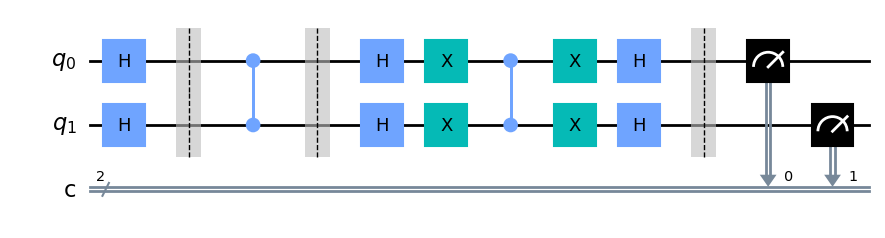

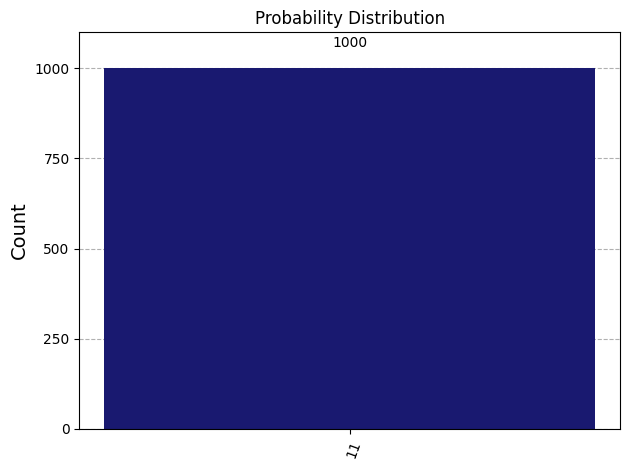

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def build_grover_circuit():
    """Builds a 2-qubit Grover's algorithm searching for the state |11>."""

    # Initialize a 2-qubit circuit with 2 classical bits for measurement
    qc = QuantumCircuit(2, 2)

    # --- 1. Initialization ---
    # Apply Hadamard gates to create an equal superposition of all 4 states
    qc.h([0, 1])
    qc.barrier()

    # --- 2. The Oracle ---
    # We are searching for the state |11>.
    # A Controlled-Z (CZ) gate flips the phase ONLY if both qubits are 1.
    qc.cz(0, 1)
    qc.barrier()

    # --- 3. The Diffuser (Amplitude Amplification) ---
    # Apply H gates to transition out of the computational basis
    qc.h([0, 1])
    # Apply X gates to flip the states
    qc.x([0, 1])
    # Apply CZ gate to reflect around the mean
    qc.cz(0, 1)
    # Undo the X and H gates
    qc.x([0, 1])
    qc.h([0, 1])
    qc.barrier()

    # --- 4. Measurement ---
    qc.measure([0, 1], [0, 1])

    # Execute the simulation
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1000)
    result = job.result()
    counts = result.get_counts(qc)

    print("--- Grover's Search Results ---")
    print(f"Target state: '11'")
    print(f"Measurement outcomes: {counts}")

    # Verify the target was found with maximum probability
    if '11' in counts and counts['11'] == 1000:
        print("SUCCESS! Amplitude amplification isolated the |11> state perfectly.")

    # Draw the circuit
    display(qc.draw('mpl', style='clifford'))

    # Plot the histogram to visually prove the 100% probability
    display(plot_histogram(counts, title="Probability Distribution", color='midnightblue'))

# Run the algorithm
build_grover_circuit()